# Carga, diagnóstico e primeiro cruzamento
### Tema 1 — Economia e emprego formal (Ceará)

Cobre os itens 2, 3 e 4 do acompanhamento obrigatório: inventário das
tabelas, diagnóstico de qualidade e primeiro cruzamento reproduzível
(PIB × população, 2022).

In [1]:
import sys
sys.path.append("../src")

import pandas as pd
import matplotlib.pyplot as plt
from io_dados import (
    carregar_todas_as_bases, carregar_malha_municipal,
    filtrar_municipios, SIMBOLOS_ESPECIAIS_SIDRA,
)

pd.set_option("display.max_columns", None)

bases = carregar_todas_as_bases()
malha = carregar_malha_municipal()
for nome, df in bases.items():
    print(f"{nome}: {df.shape[0]} linhas")
print(f"malha: {malha.shape[0]} municípios")

cempre: 1116 linhas
estrutura_2021: 1860 linhas
pib_2022: 186 linhas
censo_2022: 558 linhas
malha: 184 municípios


## Inventário e diagnóstico de qualidade

In [2]:
chave = ["territorio_codigo", "ano_codigo", "variavel_codigo"]

for nome, df in bases.items():
    n_dup = df.duplicated(subset=chave).sum()
    n_mun = filtrar_municipios(df)["territorio_codigo"].nunique()
    n_simbolos = df["valor"].astype(str).isin(SIMBOLOS_ESPECIAIS_SIDRA).sum()
    ano = df["ano_nome"].unique()
    n_vars = df["variavel_codigo"].nunique()
    print(f"{nome:16s} | ano={list(ano)} | {n_vars} variáveis | "
          f"{n_mun}/184 municípios | {n_dup} duplicatas | {n_simbolos} símbolos especiais")

cempre           | ano=[np.int64(2022)] | 6 variáveis | 184/184 municípios | 0 duplicatas | 0 símbolos especiais
estrutura_2021   | ano=[np.int64(2021)] | 10 variáveis | 184/184 municípios | 0 duplicatas | 0 símbolos especiais
pib_2022         | ano=[np.int64(2022)] | 1 variáveis | 184/184 municípios | 0 duplicatas | 0 símbolos especiais
censo_2022       | ano=[np.int64(2022)] | 3 variáveis | 184/184 municípios | 0 duplicatas | 0 símbolos especiais


Resultado: nenhuma duplicata, 184/184 municípios em todas as bases,
zero símbolos especiais nas variáveis selecionadas. Detalhe de variáveis
e unidades de cada tabela está em `dados/raw/README_DADOS.md`.

## Primeiro cruzamento reproduzível: PIB × população (2022)

Junção pelo `territorio_codigo` (código IBGE do município), com
`how="outer"` para expor eventuais municípios sem par.

In [3]:
pib_mun = filtrar_municipios(bases["pib_2022"])[
    ["territorio_codigo", "territorio_nome", "valor"]
].rename(columns={"valor": "pib_mil_reais_2022"})

pop_mun = filtrar_municipios(bases["censo_2022"])
pop_mun = pop_mun[pop_mun["variavel_codigo"] == "93"][
    ["territorio_codigo", "valor"]
].rename(columns={"valor": "populacao_2022"})

cruzamento = pib_mun.merge(pop_mun, on="territorio_codigo", how="outer", indicator=True)

n_total = cruzamento.shape[0]
n_both = (cruzamento["_merge"] == "both").sum()
print(f"Cardinalidade esperada: 184 municípios (1:1)")
print(f"Correspondência completa: {n_both}/{n_total} ({100*n_both/n_total:.1f}%)")

cruzamento = cruzamento[cruzamento["_merge"] == "both"].copy()
cruzamento["pib_per_capita_2022"] = cruzamento["pib_mil_reais_2022"] * 1000 / cruzamento["populacao_2022"]

caminho_saida = "../dados/analytical/pib_per_capita_2022.csv"
cruzamento.to_csv(caminho_saida, index=False, sep=";", encoding="utf-8-sig")
print(f"Salvo em {caminho_saida}")

cruzamento[["territorio_nome", "populacao_2022", "pib_per_capita_2022"]] \
    .sort_values("pib_per_capita_2022", ascending=False).head(5)

Cardinalidade esperada: 184 municípios (1:1)
Correspondência completa: 184/184 (100.0%)
Salvo em ../dados/analytical/pib_per_capita_2022.csv


,territorio_nome,populacao_2022,pib_per_capita_2022
161,São Gonçalo do Amarante - CE,54143.0,127332.342131
55,Eusébio - CE,74170.0,61444.195766
103,Maracanaú - CE,234509.0,59720.241014
11,Aquiraz - CE,80645.0,54920.329841
139,Pereiro - CE,15274.0,34729.082100


## Duas visualizações preliminares

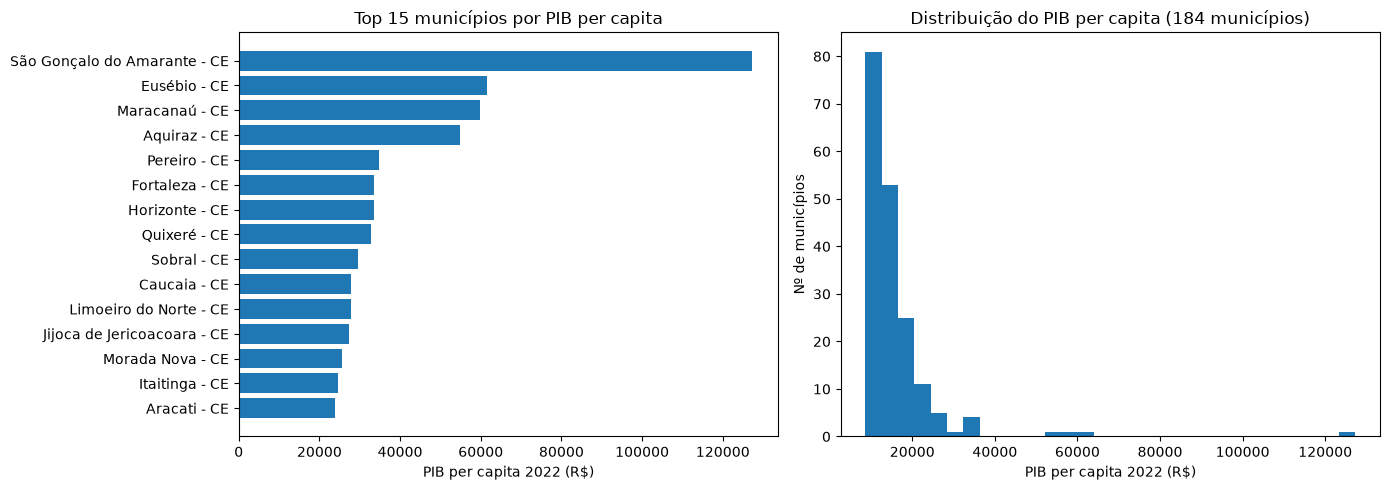

count       184.000000
mean      15991.005511
std       11164.567540
min        8598.717707
25%       11217.729955
50%       13087.736303
75%       16864.710347
max      127332.342131
Name: pib_per_capita_2022, dtype: float64

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

top15 = cruzamento.sort_values("pib_per_capita_2022", ascending=False).head(15)
axes[0].barh(top15["territorio_nome"], top15["pib_per_capita_2022"])
axes[0].invert_yaxis()
axes[0].set_xlabel("PIB per capita 2022 (R$)")
axes[0].set_title("Top 15 municípios por PIB per capita")

axes[1].hist(cruzamento["pib_per_capita_2022"], bins=30)
axes[1].set_xlabel("PIB per capita 2022 (R$)")
axes[1].set_ylabel("Nº de municípios")
axes[1].set_title("Distribuição do PIB per capita (184 municípios)")

plt.tight_layout()
plt.savefig("../dados/analytical/graficos_pib_per_capita_2022.png", dpi=150)
plt.show()

cruzamento["pib_per_capita_2022"].describe()

## Interpretação inicial (rascunho — ajustar com a equipe)

- **Empírico**: cruzamento PIB × população teve 184/184 correspondência (100%).
- **Empírico**: distribuição do PIB per capita é assimétrica — poucos
  municípios concentram valores bem acima da média (ex.: São Gonçalo do
  Amarante).
- **Interpretação**: possível concentração espacial da produção
  econômica, a confirmar cruzando com a estrutura setorial (2021).
- **Limitação**: PIB per capita é média municipal, não mede desigualdade
  interna nem renda das famílias.

## Próximos passos
- [ ] Cruzar estrutura setorial (2021) com CEMPRE/salário (2022) — associação exploratória, defasagem de 1 ano
- [ ] Wireframe funcional do dashboard (`app/app.py`)
